Check how many questions and KCs have 90% of correct response
- Look at guidelines for learning engineering
- How CMU suggests learning with PyBKT, how they suggest guidelines for creating courses. Look at pyBKT extended paper.
- Do the same analysis on both aggregation types both combined and aggregated.


This is counterintuitive but important. If you had to choose between giving each student 10 more questions per KC or enrolling 10 more students, enrolling more students does more to improve BKT reliability. More students is more valuable than more questions per student.

**Look at distribution of correct/pass questions to see if theres a specific region that is highly represented**

See distribution of correct/pass rate to see if there is a specific region that is highly represented
E.g a lot of questions that have many students that got it correct

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


base_path = Path().resolve().parent
file_path = base_path / 'data' / 'raw' 

In [2]:
data = pd.read_excel(file_path / 'Stellar_edu_MDS_ap_stats_dataset - v1.9.xlsx', sheet_name='Student_Observations')

In [3]:
# new KC Maps
mkc_maps = pd.read_excel(file_path / 'mkc_mapping_pack_v1.0..xlsx', sheet_name='FineKC_to_ModelingKC_Map')

In [4]:
mkc_map = mkc_maps[['fine_kc_id', 'modeling_kc_id']]

In [5]:
mkc_map.nunique()

fine_kc_id        256
modeling_kc_id     47
dtype: int64

In [6]:
data_mkc = data.copy()

In [7]:
mkc_map

,fine_kc_id,modeling_kc_id
0,KC.U1.01.statistical_context,MKC.U1.01.data_context_variables
1,KC.U1.02.observational_unit_variable,MKC.U1.01.data_context_variables
2,KC.U1.03.variable_type_cat_quant,MKC.U1.01.data_context_variables
3,KC.U1.04.variable_type_discrete_continuous,MKC.U1.01.data_context_variables
4,KC.U1.05.categorical_freq_relative,MKC.U1.02.categorical_tables_displays
...,...,...
251,KC.U10.14.power_beta_relationship_extension,MKC.U10.04.power_typeii_tradeoffs
252,KC.U10.15.rejection_region_power_calculation,MKC.U10.04.power_typeii_tradeoffs
253,KC.U10.16.factors_affecting_power,MKC.U10.04.power_typeii_tradeoffs
254,KC.U10.17.power_specific_alternative,MKC.U10.04.power_typeii_tradeoffs


In [8]:
data_mkc['new_kc_id'] = data_mkc['primary_kc_id'].map(mkc_map.set_index('fine_kc_id')['modeling_kc_id'])

In [9]:
data_mkc.head(2)

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,student_response,correct_answer_or_rubric,rubric_level,new_kc_id
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.0,1,0,C,E,NaN,MKC.U1.01.data_context_variables
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.0,1,100,E,E,NaN,MKC.U1.01.data_context_variables


In [10]:
data_mkc.to_csv(base_path / 'data' / 'processed' / 'data_with_aggregated_kcs.csv', index=False)

In [11]:
data['primary_kc_id'].nunique()

236

In [13]:
data_mkc.nunique()

student_id                   25
assignment_id                33
class_num                    27
observation_id              895
item_type                     3
source_question             640
primary_kc_id               236
all_kc_ids                  521
score                         3
max_score                     1
percent_score                 3
student_response             25
correct_answer_or_rubric    185
rubric_level                  3
new_kc_id                    47
dtype: int64

In [12]:
data.head()

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,student_response,correct_answer_or_rubric,rubric_level
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.0,1,0,C,E,NaN
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.0,1,100,E,E,NaN
2,S001,HW1,1,HW1_PCA_Q03,MCQ,PCA Q03,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,0.0,1,0,C,D,NaN
3,S001,HW1,1,HW1_PCA_Q04,MCQ,PCA Q04,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100,E,E,NaN
4,S001,HW1,1,HW1_PCA_Q05,MCQ,PCA Q05,KC.U1.05.categorical_freq_relative,KC.U1.05.categorical_freq_relative,1.0,1,100,B,B,NaN


In [13]:
data.columns

Index(['student_id', 'assignment_id', 'class_num', 'observation_id',
       'item_type', 'source_question', 'primary_kc_id', 'all_kc_ids', 'score',
       'max_score', 'percent_score', 'student_response',
       'correct_answer_or_rubric', 'rubric_level'],
      dtype='str')

In [14]:
data[data['score'] == 0.5]
data_mkc[data_mkc['score'] == 0.5]

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,student_response,correct_answer_or_rubric,rubric_level,new_kc_id
66,S001,HW3,3,HW3_PCFRQ_Q1c,FRQ_Component,PCFRQ Q1c,KC.U1.20.normal_model_appropriateness,KC.U1.20.normal_model_appropriateness|KC.U1.10...,0.5,1,50,P,Rubric: no; not mound-shaped/normal; justify u...,P,MKC.U1.06.normal_distribution_calculations
113,S002,HW2,2,HW2_SGFRQ1_Q1b,FRQ_Component,SGFRQ1 Q1b,KC.U1.16.resistance_skew_mean_median,KC.U1.16.resistance_skew_mean_median|KC.U1.10....,0.5,1,50,P,Rubric: mean overestimates typical price becau...,P,MKC.U1.04.summary_statistics_outliers
136,S002,HW3,3,HW3_PCFRQ_Q2a,FRQ_Component,PCFRQ Q2a,KC.U1.19.z_score_compute_interpret,KC.U1.19.z_score_compute_interpret,0.5,1,50,P,Rubric: z = 1 for north and z = -1.2 for south...,P,MKC.U1.05.standardization_transformations
205,S003,HW3,3,HW3_PCFRQ_Q2a,FRQ_Component,PCFRQ Q2a,KC.U1.19.z_score_compute_interpret,KC.U1.19.z_score_compute_interpret,0.5,1,50,P,Rubric: z = 1 for north and z = -1.2 for south...,P,MKC.U1.05.standardization_transformations
251,S004,HW2,2,HW2_SGFRQ1_Q1b,FRQ_Component,SGFRQ1 Q1b,KC.U1.16.resistance_skew_mean_median,KC.U1.16.resistance_skew_mean_median|KC.U1.10....,0.5,1,50,P,Rubric: mean overestimates typical price becau...,P,MKC.U1.04.summary_statistics_outliers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21747,S025,MF1,27,MF1_FRQ6E,FRQ_Component,Investigative Q1,KC.U10.07.bootstrap_interval_interpret_context,KC.U10.07.bootstrap_interval_interpret_context...,0.5,1,50,P,Rubric: use percentile endpoints and interpret...,P,MKC.U10.02.bootstrap_intervals
21791,S025,MF2,27,MF2_FRQ2A,FRQ_Component,FRQ 2,KC.U7.20.two_sample_t_interval_compute_interpret,KC.U7.20.two_sample_t_interval_compute_interpr...,0.5,1,50,P,Rubric: select two-sample or randomized-compar...,P,MKC.U7.04.two_sample_t_intervals
21794,S025,MF2,27,MF2_FRQ3A,FRQ_Component,FRQ 1,KC.U4.16.expected_value_calculation,KC.U4.16.expected_value_calculation|KC.U4.17.e...,0.5,1,50,P,Rubric: use n times p and state the expected n...,P,MKC.U4.03.random_variables_expected_value
21801,S025,MF2,27,MF2_FRQ5B,FRQ_Component,FRQ 1,KC.U9.19.lsrl_equation_from_data,KC.U9.19.lsrl_equation_from_data|KC.U9.14.slop...,0.5,1,50,P,Rubric: write LSRL equation and state H0/H_a f...,P,MKC.U9.01.slope_inference_foundations_ci


In [15]:
question_difficulty = (data[data['score'] != 0.5]
    .assign(correct=lambda df: df['score'].astype(int))
    .groupby('observation_id')       
    .agg(
        correct_rate = ('correct', 'mean'),
        n_students   = ('correct', 'count')
    )
    .reset_index()
    .sort_values('correct_rate', ascending=False)
)

question_difficulty.head()
len(question_difficulty)

895

In [16]:
too_easy_questions = question_difficulty[question_difficulty['correct_rate'] >= 0.80]
print(f"Questions with ≥ 80% correct rate: {len(too_easy_questions)}")
print(too_easy_questions)

Questions with ≥ 80% correct rate: 24
        observation_id  correct_rate  n_students
349        HW2_PCA_Q13      0.880000          25
511       HW7_U4PA_Q05      0.880000          25
561       HW9_U4FRQ2_a      0.857143          14
47    HW11_U5FRQ2_Q2ci      0.842105          19
572       HW9_U4PB_Q10      0.840000          25
500      HW7_SG34_Q112      0.840000          25
182        HW1_PCA_Q02      0.840000          25
193        HW1_SG1_Q24      0.840000          25
72        HW13_U5C_Q06      0.833333          24
576          ME1_FRQ1a      0.823529          17
61    HW12_U5FRQ1_Q1a1      0.823529          17
149  HW17_U6FRQ2_Q2d_i      0.812500          16
627         ME2_FRQ04a      0.812500          16
787          MF1_FRQ5A      0.800000          15
502      HW7_SG34_Q120      0.800000          25
355        HW2_PCB_Q01      0.800000          25
381      HW3_PCFRQ_Q1c      0.800000          20
401      HW4_U2PCA_Q05      0.800000          25
16       HW10_U4PC_Q01      0.8

In [17]:
hard_questions = question_difficulty[question_difficulty['correct_rate']<= 0.30]
print(f"Questions with ≤ 30% correct rate: {len(hard_questions)}")
print(hard_questions)

Questions with ≤ 30% correct rate: 38
          observation_id  correct_rate  n_students
831            MF1_MCQ37      0.291667          24
818            MF1_MCQ24      0.291667          24
798            MF1_MCQ04      0.291667          24
796            MF1_MCQ02      0.291667          24
824            MF1_MCQ30      0.291667          24
889            MF2_MCQ35      0.291667          24
435      HW4_U2PCFRQ_Q2d      0.291667          24
849            MF2_FRQ5C      0.285714          21
740            ME4_MCQ21      0.280000          25
733            ME4_MCQ14      0.280000          25
613            ME1_MCQ26      0.280000          25
837            MF2_FRQ1C      0.277778          18
329       HW27_PWR_FRQ18      0.277778          18
778            MF1_FRQ2A      0.266667          15
839            MF2_FRQ2B      0.266667          15
221        HW20_U7FRQ1_b      0.263158          19
250         HW22_U8B_Q11      0.260870          23
248         HW22_U8B_Q09      0.260870      

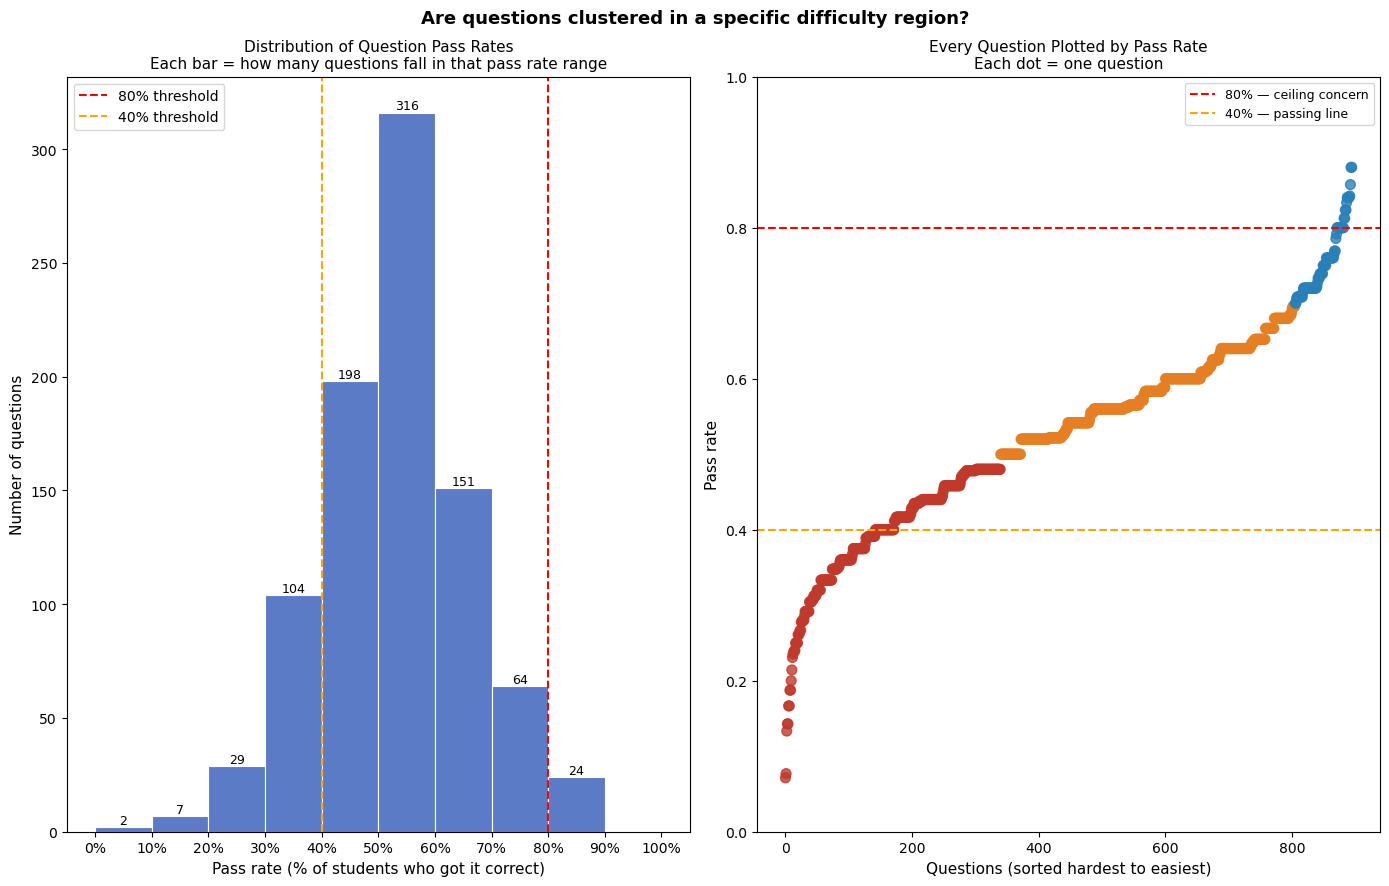

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Chart 1: Histogram — how many questions fall in each pass rate range 
ax = axes[0]
ax.hist(question_difficulty['correct_rate'], bins=10, range=(0, 1),
        color='#5B7BC6', edgecolor='white', linewidth=0.8)


# Mark the 80% threshold
ax.axvline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')
ax.axvline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% threshold')

ax.set_xlabel('Pass rate (% of students who got it correct)', fontsize=11)
ax.set_ylabel('Number of questions', fontsize=11)
ax.set_title('Distribution of Question Pass Rates\n'
             'Each bar = how many questions fall in that pass rate range', fontsize=11)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_xticklabels(['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
ax.legend()


# Annotate each bar with the count
counts, edges = np.histogram(question_difficulty['correct_rate'], bins=10, range=(0,1))
for count, edge in zip(counts, edges):
    if count > 0:
        ax.text(edge + 0.05, count + 0.1, str(count),
                ha='center', va='bottom', fontsize=9)

# Chart 2: Every question as a dot, sorted by pass rate
ax = axes[1]
sorted_q = question_difficulty.sort_values('correct_rate').reset_index(drop=True)
colors = ['#C0392B' if p < 0.5 else ('#E67E22' if p < 0.7 else
          ('#2980B9' if p < 0.9 else '#27AE60'))
          for p in sorted_q['correct_rate']]
ax.scatter(range(len(sorted_q)), sorted_q['correct_rate'],
           c=colors, s=50, alpha=0.8)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% — ceiling concern')
ax.axhline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% — passing line')
ax.set_xlabel('Questions (sorted hardest to easiest)', fontsize=11)
ax.set_ylabel('Pass rate', fontsize=11)
ax.set_title('Every Question Plotted by Pass Rate\n'
             'Each dot = one question', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

plt.suptitle('Are questions clustered in a specific difficulty region?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
#  how many questions fall in each region
bins = [0, 0.5, 0.7, 0.9, 1.01]
labels = ['Hard (0–50%)', 'Medium (50–70%)', 'Easy (70–90%)', 'Very Easy (90–100%)']

question_difficulty['difficulty_band'] = pd.cut(
    question_difficulty['correct_rate'],
    bins=bins, labels=labels, right=False
)

summary = question_difficulty['difficulty_band'].value_counts().reindex(labels)
summary_pct = (summary / len(question_difficulty) * 100).round(1)

print("Pass rate distribution across questions:")
print("=" * 50)
for band, count, pct in zip(labels, summary.values, summary_pct.values):
    bar = '█' * int(pct / 2)
    print(f"  {band:22} {count:3d} questions ({pct:.1f}%)  {bar}")

print(f"\nTotal questions: {len(question_difficulty)}")
print(f"\nConclusion:")
dominant = summary.idxmax()
print(f"  Most questions fall in the '{dominant}' band ({summary.max()} questions)")

Pass rate distribution across questions:
  Hard (0–50%)           340 questions (38.0%)  ███████████████████
  Medium (50–70%)        465 questions (52.0%)  ██████████████████████████
  Easy (70–90%)           90 questions (10.1%)  █████
  Very Easy (90–100%)      0 questions (0.0%)  

Total questions: 895

Conclusion:
  Most questions fall in the 'Medium (50–70%)' band (465 questions)


In [20]:
#question_difficulty.to_csv(base_path / 'data' / 'processed' / 'question_difficulty.csv', index=False)

KC Before Aggregation

In [21]:
kc_difficulty = (data[data['score'] != 0.5]
    .assign(correct=lambda df: df['score'].astype(int))
    .groupby('primary_kc_id')       
    .agg(
        correct_rate = ('correct', 'mean'),
        n_obs   = ('correct', 'count'),
        n_students   = ('student_id', 'nunique')
    )
    .reset_index()
    .sort_values('correct_rate', ascending=False)
)

kc_difficulty.head()
len(kc_difficulty)

236

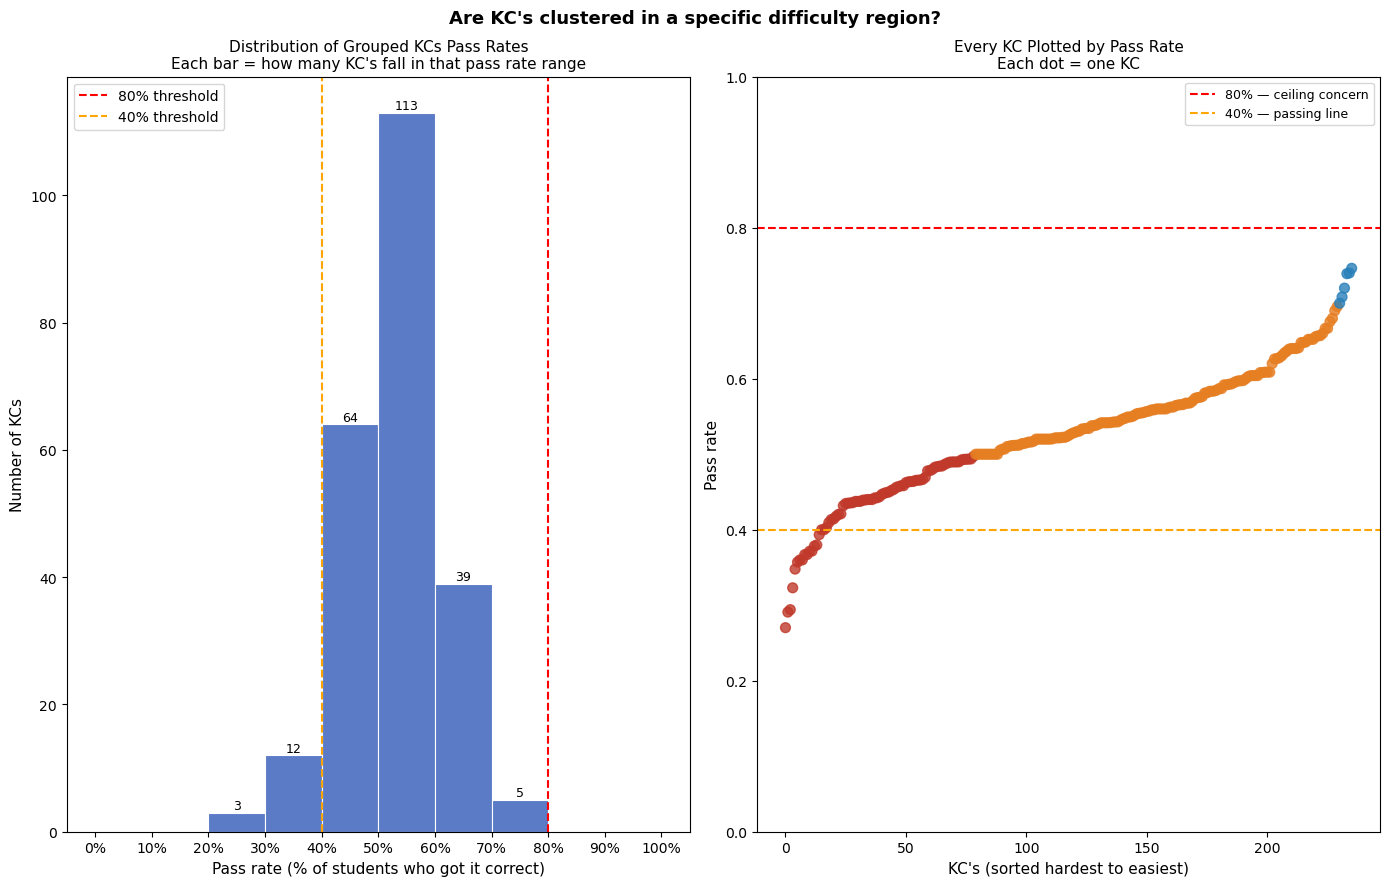

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Chart 1: Histogram — how many questions fall in each pass rate range 
ax = axes[0]
ax.hist(kc_difficulty['correct_rate'], bins=10, range=(0, 1),
        color='#5B7BC6', edgecolor='white', linewidth=0.8)


# Mark the 80% threshold
ax.axvline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')
ax.axvline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% threshold')

ax.set_xlabel('Pass rate (% of students who got it correct)', fontsize=11)
ax.set_ylabel('Number of KCs', fontsize=11)
ax.set_title('Distribution of Grouped KCs Pass Rates\n'
             "Each bar = how many KC's fall in that pass rate range", fontsize=11)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_xticklabels(['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
ax.legend()


# Annotate each bar with the count
counts, edges = np.histogram(kc_difficulty['correct_rate'], bins=10, range=(0,1))
for count, edge in zip(counts, edges):
    if count > 0:
        ax.text(edge + 0.05, count + 0.1, str(count),
                ha='center', va='bottom', fontsize=9)

# Chart 2: Every KC as a dot, sorted by pass rate
ax = axes[1]
sorted_q = kc_difficulty.sort_values('correct_rate').reset_index(drop=True)
colors = ['#C0392B' if p < 0.5 else ('#E67E22' if p < 0.7 else
          ('#2980B9' if p < 0.9 else '#27AE60'))
          for p in sorted_q['correct_rate']]
ax.scatter(range(len(sorted_q)), sorted_q['correct_rate'],
           c=colors, s=50, alpha=0.8)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% — ceiling concern')
ax.axhline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% — passing line')
ax.set_xlabel("KC's (sorted hardest to easiest)", fontsize=11)
ax.set_ylabel('Pass rate', fontsize=11)
ax.set_title('Every KC Plotted by Pass Rate\n'
             'Each dot = one KC', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

plt.suptitle("Are KC's clustered in a specific difficulty region?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
#  how many kcs fall in each region
bins = [0, 0.5, 0.7, 0.9, 1.01]
labels = ['Hard (0–50%)', 'Medium (50–70%)', 'Easy (70–90%)', 'Very Easy (90–100%)']

kc_difficulty['difficulty_band'] = pd.cut(
    kc_difficulty['correct_rate'],
    bins=bins, labels=labels, right=False
)

summary = kc_difficulty['difficulty_band'].value_counts().reindex(labels)
summary_pct = (summary / len(kc_difficulty) * 100).round(1)

print("Pass rate distribution across KCs:")
print("=" * 50)
for band, count, pct in zip(labels, summary.values, summary_pct.values):
    bar = '█' * int(pct / 2)
    print(f"  {band:22} {count:3d} kcs ({pct:.1f}%)  {bar}")

print(f"\nTotal kcs: {len(kc_difficulty)}")
print(f"\nConclusion:")
dominant = summary.idxmax()
print(f"  Most kcs fall in the '{dominant}' band ({summary.max()} kcs)")

Pass rate distribution across KCs:
  Hard (0–50%)            79 kcs (33.5%)  ████████████████
  Medium (50–70%)        151 kcs (64.0%)  ████████████████████████████████
  Easy (70–90%)            6 kcs (2.5%)  █
  Very Easy (90–100%)      0 kcs (0.0%)  

Total kcs: 236

Conclusion:
  Most kcs fall in the 'Medium (50–70%)' band (151 kcs)


KC After Aggregation

In [24]:
kc_difficulty_mkc = (data_mkc[data_mkc['score'] != 0.5]
    .assign(correct=lambda df: df['score'].astype(int))
    .groupby('new_kc_id')       
    .agg(
        correct_rate = ('correct', 'mean'),
        n_obs   = ('correct', 'count'),
        n_students   = ('student_id', 'nunique')
    )
    .reset_index()
    .sort_values('correct_rate', ascending=False)
)

kc_difficulty_mkc.head()
len(kc_difficulty_mkc)

47

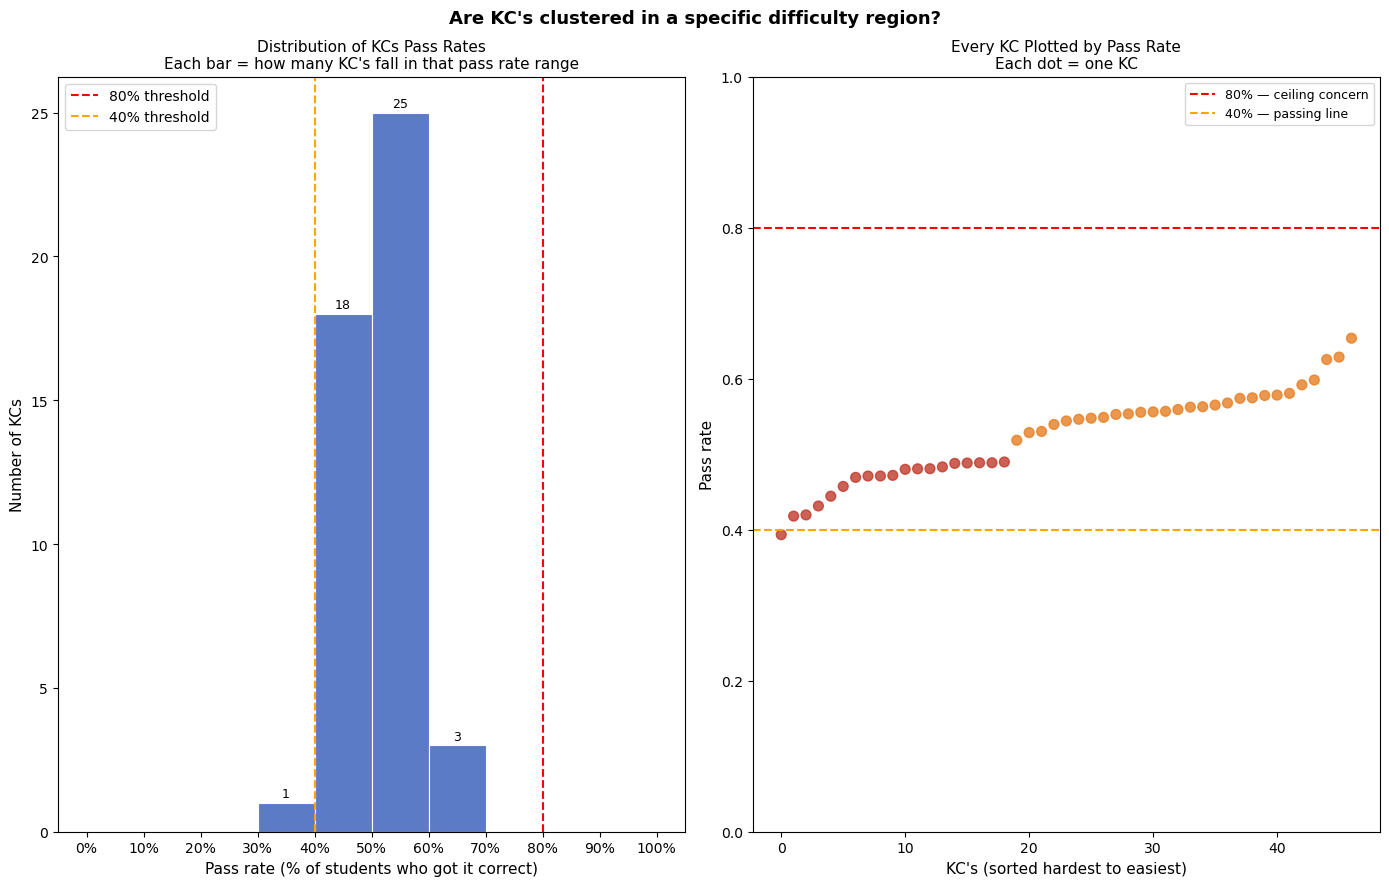

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Chart 1: Histogram — how many questions fall in each pass rate range 
ax = axes[0]
ax.hist(kc_difficulty_mkc['correct_rate'], bins=10, range=(0, 1),
        color='#5B7BC6', edgecolor='white', linewidth=0.8)


# Mark the 80% threshold
ax.axvline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% threshold')
ax.axvline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% threshold')

ax.set_xlabel('Pass rate (% of students who got it correct)', fontsize=11)
ax.set_ylabel('Number of KCs', fontsize=11)
ax.set_title('Distribution of KCs Pass Rates\n'
             "Each bar = how many KC's fall in that pass rate range", fontsize=11)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_xticklabels(['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
ax.legend()


# Annotate each bar with the count
counts, edges = np.histogram(kc_difficulty_mkc['correct_rate'], bins=10, range=(0,1))
for count, edge in zip(counts, edges):
    if count > 0:
        ax.text(edge + 0.05, count + 0.1, str(count),
                ha='center', va='bottom', fontsize=9)

# Chart 2: Every KC as a dot, sorted by pass rate
ax = axes[1]
sorted_q = kc_difficulty_mkc.sort_values('correct_rate').reset_index(drop=True)
colors = ['#C0392B' if p < 0.5 else ('#E67E22' if p < 0.7 else
          ('#2980B9' if p < 0.9 else '#27AE60'))
          for p in sorted_q['correct_rate']]
ax.scatter(range(len(sorted_q)), sorted_q['correct_rate'],
           c=colors, s=50, alpha=0.8)
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='80% — ceiling concern')
ax.axhline(0.40, color='orange', linestyle='--', linewidth=1.5, label='40% — passing line')
ax.set_xlabel("KC's (sorted hardest to easiest)", fontsize=11)
ax.set_ylabel('Pass rate', fontsize=11)
ax.set_title('Every KC Plotted by Pass Rate\n'
             'Each dot = one KC', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

plt.suptitle("Are KC's clustered in a specific difficulty region?",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
#  how many kcs fall in each region
bins = [0, 0.5, 0.7, 0.9, 1.01]
labels = ['Hard (0–50%)', 'Medium (50–70%)', 'Easy (70–90%)', 'Very Easy (90–100%)']

kc_difficulty_mkc['difficulty_band'] = pd.cut(
    kc_difficulty_mkc['correct_rate'],
    bins=bins, labels=labels, right=False
)

summary = kc_difficulty_mkc['difficulty_band'].value_counts().reindex(labels)
summary_pct = (summary / len(kc_difficulty_mkc) * 100).round(1)

print("Pass rate distribution across KCs:")
print("=" * 50)
for band, count, pct in zip(labels, summary.values, summary_pct.values):
    bar = '█' * int(pct / 2)
    print(f"  {band:22} {count:3d} kcs ({pct:.1f}%)  {bar}")

print(f"\nTotal kcs after Grouping: {len(kc_difficulty_mkc)}")
print(f"\nConclusion:")
dominant = summary.idxmax()
print(f"  Most kcs fall in the '{dominant}' band ({summary.max()} kcs)")

Pass rate distribution across KCs:
  Hard (0–50%)            19 kcs (40.4%)  ████████████████████
  Medium (50–70%)         28 kcs (59.6%)  █████████████████████████████
  Easy (70–90%)            0 kcs (0.0%)  
  Very Easy (90–100%)      0 kcs (0.0%)  

Total kcs after Grouping: 47

Conclusion:
  Most kcs fall in the 'Medium (50–70%)' band (28 kcs)


In [27]:
kc_difficulty

,primary_kc_id,correct_rate,n_obs,n_students,difficulty_band
124,KC.U5.06.point_estimator_statistic_parameter,0.746269,67,24,Easy (70–90%)
6,KC.U1.08.graph_choice_categorical,0.740000,50,25,Easy (70–90%)
28,KC.U10.03.bootstrap_same_sample_size,0.739130,23,23,Easy (70–90%)
50,KC.U2.08.explanatory_response_variables,0.720000,25,25,Easy (70–90%)
205,KC.U8.10.chi_square_distribution_shape,0.708333,24,24,Easy (70–90%)
...,...,...,...,...,...
191,KC.U7.21.two_sample_t_interval_claim_plausibility,0.347826,46,23,Hard (0–50%)
59,KC.U2.18.standard_deviation_residuals,0.323077,65,25,Hard (0–50%)
197,KC.U7.27.multiple_comparisons_alpha_adjustment,0.294118,34,24,Hard (0–50%)
40,KC.U10.15.rejection_region_power_calculation,0.290909,55,24,Hard (0–50%)


In [28]:
kc_difficulty_mkc.head(200)

,new_kc_id,correct_rate,n_obs,n_students,difficulty_band
26,MKC.U5.02.sample_proportion_sampling_distribution,0.653659,205,25,Medium (50–70%)
1,MKC.U1.02.categorical_tables_displays,0.628692,474,25,Medium (50–70%)
0,MKC.U1.01.data_context_variables,0.625468,267,25,Medium (50–70%)
20,MKC.U4.01.probability_foundations_simulation,0.598322,1073,25,Medium (50–70%)
13,MKC.U2.04.regression_prediction_interpretation,0.591928,223,25,Medium (50–70%)
5,MKC.U1.06.normal_distribution_calculations,0.580583,515,25,Medium (50–70%)
3,MKC.U1.04.summary_statistics_outliers,0.578313,581,25,Medium (50–70%)
45,MKC.U9.02.regression_conditions_diagnostics_scope,0.577778,360,25,Medium (50–70%)
25,MKC.U5.01.normal_simulation_estimators,0.574746,689,25,Medium (50–70%)
29,MKC.U5.05.diff_means_sampling_distribution,0.573964,169,25,Medium (50–70%)


In [29]:
#kc_difficulty.to_csv(base_path / 'data' / 'processed' / 'kc_difficulty.csv', index=False)

In [30]:
too_easy_kc = kc_difficulty[kc_difficulty['correct_rate'] >= 0.70]
print(f"Knowledge components with ≥ 70% correct rate: {len(too_easy_kc)}")
too_easy_kc

Knowledge components with ≥ 70% correct rate: 6


,primary_kc_id,correct_rate,n_obs,n_students,difficulty_band
124,KC.U5.06.point_estimator_statistic_parameter,0.746269,67,24,Easy (70–90%)
6,KC.U1.08.graph_choice_categorical,0.740000,50,25,Easy (70–90%)
28,KC.U10.03.bootstrap_same_sample_size,0.739130,23,23,Easy (70–90%)
50,KC.U2.08.explanatory_response_variables,0.720000,25,25,Easy (70–90%)
205,KC.U8.10.chi_square_distribution_shape,0.708333,24,24,Easy (70–90%)
180,KC.U7.09.generalization_scope_quantitative_inf...,0.700000,10,10,Easy (70–90%)


In [31]:
too_easy_mkc = kc_difficulty_mkc[kc_difficulty_mkc['correct_rate'] >= 0.70]
print(f"Knowledge components with ≥ 70% correct rate: {len(too_easy_mkc)}")
too_easy_mkc

Knowledge components with ≥ 70% correct rate: 0


,new_kc_id,correct_rate,n_obs,n_students,difficulty_band


In [32]:
too_hard_kc = kc_difficulty[kc_difficulty['correct_rate'] <= 0.30]
print(f"Knowledge components with ≤ 30% correct rate: {len(too_hard_kc)}")
too_hard_kc

Knowledge components with ≤ 30% correct rate: 3


,primary_kc_id,correct_rate,n_obs,n_students,difficulty_band
197,KC.U7.27.multiple_comparisons_alpha_adjustment,0.294118,34,24,Hard (0–50%)
40,KC.U10.15.rejection_region_power_calculation,0.290909,55,24,Hard (0–50%)
176,KC.U7.05.one_sample_t_interval_compute,0.270270,37,23,Hard (0–50%)


In [33]:
too_hard_mkc = kc_difficulty_mkc[kc_difficulty_mkc['correct_rate'] <= 0.30]
print(f"Knowledge components with ≤ 30% correct rate: {len(too_hard_mkc)}")
too_hard_mkc

Knowledge components with ≤ 30% correct rate: 0


,new_kc_id,correct_rate,n_obs,n_students,difficulty_band


In [34]:
total_students = data['student_id'].nunique()
total_questions = data['source_question'].nunique()
total_kcs = data['primary_kc_id'].nunique()
total_obs = len(data)

print(f"Total Unique Students: {total_students}")
print(f"Total Unique Questions (Items): {total_questions}")
print(f"Total Unique KCs: {total_kcs}")
print(f"Total Graded Observations: {total_obs}\n")

Total Unique Students: 25
Total Unique Questions (Items): 640
Total Unique KCs: 236
Total Graded Observations: 21808



In [35]:
total_students = data_mkc['student_id'].nunique()
total_questions = data_mkc['source_question'].nunique()
total_mkc = data_mkc['new_kc_id'].nunique()
total_obs = len(data_mkc)

print(f"Total Unique Students: {total_students}")
print(f"Total Unique Questions (Items): {total_questions}")
print(f"Total Unique KCs: {total_mkc}")
print(f"Total Graded Observations: {total_obs}\n")

Total Unique Students: 25
Total Unique Questions (Items): 640
Total Unique KCs: 47
Total Graded Observations: 21808



In [36]:
kc_success = data.groupby('primary_kc_id')['score'].mean()

print("Validating Data to Original pyBKT Recommendations:")
# 1. Vertical Depth: How many unique students attempted each KC?
students_per_kc = data.groupby('primary_kc_id')['student_id'].nunique()
low_depth_kcs = students_per_kc[students_per_kc < 100] 

# 2. Horizontal Sequence: Average number of practice opportunities (attempts) a student gets per KC
attempts_per_student_per_kc = data.groupby(['primary_kc_id', 'student_id']).size().reset_index(name='sequence_length')

avg_sequence_per_kc = attempts_per_student_per_kc.groupby('primary_kc_id')['sequence_length'].mean()
short_sequence_kcs = avg_sequence_per_kc[avg_sequence_per_kc < 15]  

print(f"KCs with low vertical depth (< 100 students): {len(low_depth_kcs)} / {total_kcs}")
print(f"KCs with shallow horizontal sequences (< 15 attempts/student): {len(short_sequence_kcs)} / {total_kcs}\n")

#
kc_summary = pd.DataFrame({
    'Success_Rate': kc_success,
    'Unique_Students': students_per_kc,
    'Avg_Sequence_Length': avg_sequence_per_kc
})


#print(kc_summary.head(10).to_string())
kc_summary.sort_values('Avg_Sequence_Length', ascending=False).head(15)

Validating Data to Original pyBKT Recommendations:
KCs with low vertical depth (< 100 students): 236 / 236
KCs with shallow horizontal sequences (< 15 attempts/student): 235 / 236



,Success_Rate,Unique_Students,Avg_Sequence_Length
primary_kc_id,,,
KC.U4.16.expected_value_calculation,0.557920,25,16.92
KC.U3.11.generalization_scope,0.568768,25,13.96
KC.U4.11.independent_events_probability,0.561728,25,12.96
KC.U2.03.conditional_relative_frequency,0.577778,25,9.00
KC.U4.01.probability_long_run_interpretation,0.633929,25,8.96
KC.U4.24.binomial_exact_probability,0.535874,25,8.92
KC.U9.08.regression_linearity_condition,0.592593,25,8.64
KC.U4.30.geometric_mean_sd,0.572500,25,8.00
KC.U1.22.normal_tail_interval_probability,0.575000,25,8.00


In [37]:
mkc_success = data_mkc.groupby('new_kc_id')['score'].mean()

print("Validating New KC-Grouped Data to Original pyBKT Recommendations:")
# 1. Vertical Depth: How many unique students attempted each KC?
students_per_mkc = data_mkc.groupby('new_kc_id')['student_id'].nunique()
low_depth_mkc = students_per_mkc[students_per_mkc < 100] 

# 2. Horizontal Sequence: Average number of practice opportunities (attempts) a student gets per KC
attempts_per_student_per_mkc = data_mkc.groupby(['new_kc_id', 'student_id']).size().reset_index(name='sequence_length')

avg_sequence_per_mkc = attempts_per_student_per_mkc.groupby('new_kc_id')['sequence_length'].mean()
short_sequence_mkc = avg_sequence_per_mkc[avg_sequence_per_mkc < 15]  

print(f"KCs with low vertical depth (< 100 students): {len(low_depth_mkc)} / {total_mkc}")
print(f"KCs with shallow horizontal sequences (< 15 attempts/student): {len(short_sequence_mkc)} / {total_mkc}\n")

#
mkc_summary = pd.DataFrame({
    'Success_Rate': mkc_success,
    'Unique_Students': students_per_mkc,
    'Avg_Sequence_Length': avg_sequence_per_mkc
})


#print(mkc_summary.head(10).to_string())
mkc_summary.sort_values('Avg_Sequence_Length', ascending=False).head(50)

Validating New KC-Grouped Data to Original pyBKT Recommendations:
KCs with low vertical depth (< 100 students): 47 / 47
KCs with shallow horizontal sequences (< 15 attempts/student): 17 / 47



,Success_Rate,Unique_Students,Avg_Sequence_Length
new_kc_id,,,
MKC.U4.03.random_variables_expected_value,0.557179,25,47.92
MKC.U4.01.probability_foundations_simulation,0.598322,25,42.92
MKC.U6.02.one_prop_hypothesis_tests,0.489231,25,39.00
MKC.U3.01.population_sampling_methods,0.545455,25,30.80
MKC.U7.03.one_sample_t_tests,0.437003,25,30.16
MKC.U5.01.normal_simulation_estimators,0.568942,25,29.88
MKC.U4.02.conditional_compound_independence,0.547718,25,28.92
MKC.U6.01.one_prop_confidence_intervals,0.490806,25,28.28
MKC.U4.04.binomial_model,0.526042,25,26.88


In [38]:
attempts_per_student_per_kc.sort_values('sequence_length', ascending=False).head(10)

,primary_kc_id,student_id,sequence_length
2541,KC.U4.16.expected_value_calculation,S011,17
2543,KC.U4.16.expected_value_calculation,S013,17
2550,KC.U4.16.expected_value_calculation,S020,17
2551,KC.U4.16.expected_value_calculation,S021,17
2552,KC.U4.16.expected_value_calculation,S022,17
2553,KC.U4.16.expected_value_calculation,S023,17
2554,KC.U4.16.expected_value_calculation,S024,17
2549,KC.U4.16.expected_value_calculation,S019,17
2555,KC.U4.16.expected_value_calculation,S025,17
2547,KC.U4.16.expected_value_calculation,S017,17


In [39]:
attempts_per_student_per_mkc.sort_values('sequence_length', ascending=False).head(10)

,new_kc_id,student_id,sequence_length
558,MKC.U4.03.random_variables_expected_value,S011,48
560,MKC.U4.03.random_variables_expected_value,S013,48
549,MKC.U4.03.random_variables_expected_value,S002,48
550,MKC.U4.03.random_variables_expected_value,S003,48
551,MKC.U4.03.random_variables_expected_value,S004,48
552,MKC.U4.03.random_variables_expected_value,S005,48
554,MKC.U4.03.random_variables_expected_value,S007,48
555,MKC.U4.03.random_variables_expected_value,S008,48
556,MKC.U4.03.random_variables_expected_value,S009,48
557,MKC.U4.03.random_variables_expected_value,S010,48
